# HTDemucs Spatial Finetune - Freeze-Strategy Comparison (test only)

This notebook **evaluates and compares** several *spatially-aware* fine-tunes of the
full HTDemucs backbone against the frozen pre-trained baseline.  Each fine-tune
differs only in its **freeze strategy** (which layers were trainable), and every
run is produced headless by

```bash
python htdemucsspatial/train.py \
    --dataset-root <binauralMUSMOISESDB> \
    --out-root     <runs-root> \
    --freeze-strategy <strategy> --epochs 100
```

Training lives entirely in that script. This notebook discovers the run directories
under `RUNS_ROOT`, loads each best checkpoint into a fresh HTDemucs, separates the
test mixtures, and reports the two metrics that matter for the trade-off between
separation quality and spatial fidelity:

- **SI-SDR** (dB) - separation quality; should stay close to the baseline.
- **Per-sub-band ILD MAE** (dB) - residual interaural level-difference error;
  lower means the binaural level cue is better preserved.

Both metrics reuse the exact sub-band cue definitions of the training loss
(`sahtdemucs.metrics`), and the band layout is read from each run's `config.json`
so the comparison is consistent with how the models were trained.

> **Prerequisite:** `pip install demucs`

In [2]:
import sys
from pathlib import Path

# Robustly locate the project root (the folder containing the `sahtdemucs` package)
_cwd = Path().resolve()
_project_root = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / 'sahtdemucs' / '__init__.py').exists()),
    _cwd.parent,
)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import json
import time
from typing import Optional

import torch
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from demucs.pretrained import get_model
from demucs.apply import apply_model
from sahtdemucs.dataset import load_audio
from sahtdemucs.spatial import mel_bin_assignment
from sahtdemucs.metrics import si_sdr, ild_bands_mae, itd_bands_mae

## Configuration

In [6]:
# ── Remote or local ───────────────────────────────────────────────────────────
remote = True

# ── Paths ─────────────────────────────────────────────────────────────────────
# RUNS_ROOT is the --out-root passed to htdemucsspatial/train.py: it holds one
# sub-directory per run, each with a `htdmcs_sp_<strategy>.pt` checkpoint and a
# `config.json`.  DATASET_ROOT/test provides the mixtures + ground-truth stems.
if remote:
    DATASET_ROOT = Path("/nas/home/macerbi/dataset/binauralmusmoisesdb")
    RUNS_ROOT    = Path("/nas/home/macerbi/sahtdemucs/runs/htdemucsspatial")
else:
    DATASET_ROOT = Path(r"D:\Polimi\PhD\Dataset\binauralMUSMOISESDB")
    RUNS_ROOT    = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs\htdemucsspatial")

# ── What to compare ───────────────────────────────────────────────────────────
# STRATEGIES = None  -> evaluate every run directory found under RUNS_ROOT.
# Otherwise give a list of run-directory names to restrict/order the comparison,
# e.g. ["dec_last1", "dec_last2", "enc_first1+dec_last1"].
STRATEGIES          = None
INCLUDE_BASELINE    = True      # also run the frozen pre-trained HTDemucs
USE_BASELINE_CACHE  = True      # reuse RUNS_ROOT/baseline_metrics.json across sessions
SAVE_ESTIMATES      = False     # write the separated stems under each run dir
COMPUTE_ITD         = False     # also compute per-band ITD MAE (GCC-PHAT, slower)
SHIFTS              = 0         # random-shift passes in apply_model; 0 = reproducible
                                # (demucs defaults to 1, which randomizes every
                                #  estimate and moves SI-SDR ~0.2 dB run to run)
LIMIT_TRACKS        = 0         # 0 = all test tracks; >0 to smoke-test the pipeline

# ── Misc ──────────────────────────────────────────────────────────────────────
SOURCES = ["drums", "bass", "other", "vocals"]
COLORS  = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]
BASELINE_LABEL = "htdemucs (baseline)"

def _pick_free_gpu() -> torch.device:
    # Return the CUDA device with the most free memory; fall back to CPU.
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0  # GPU fully occupied or unavailable
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE = _pick_free_gpu()

print(f"Dataset  : {DATASET_ROOT}")
print(f"Runs root: {RUNS_ROOT}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")

Dataset  : /nas/home/macerbi/dataset/binauralMUSMOISESDB
Runs root: /nas/home/macerbi/sahtdemucs/runs/htdemucsspatial
Device   : cuda:0
Device name: NVIDIA TITAN RTX
VRAM: 25.2 GB


## Discover the runs to compare

Each run directory produced by `htdemucsspatial/train.py` is named after its
freeze strategy (plus an optional `__tag`) and contains exactly one
`htdmcs_sp_<strategy>.pt` best checkpoint and a `config.json`.  The cell below
scans `RUNS_ROOT`, collects those runs, and reads the **sub-band cue
configuration** (FFT size, hop, number of bands, band scale, ITD settings) from
the first run's `config.json` so the ILD/ITD MAE is computed with the same band
layout the models were trained on.

In [7]:
# Fallback sub-band cue configuration, used only if a run has no config.json.
_DEFAULT_EVAL = dict(n_fft=4096, hop_length=512, n_bands=64, scale="mel",
                     max_lag=64, beta=20.0)

def _read_config(run_dir: Path) -> dict:
    cfg_path = run_dir / "config.json"
    return json.loads(cfg_path.read_text(encoding="utf-8")) if cfg_path.exists() else {}

def _eval_cfg_from(cfg: dict) -> dict:
    """Map a run's config.json onto the ild_bands_mae/itd_bands_mae kwargs."""
    if not cfg:
        return dict(_DEFAULT_EVAL)
    return dict(
        n_fft      = int(cfg.get("ild_n_fft",      _DEFAULT_EVAL["n_fft"])),
        hop_length = int(cfg.get("ild_hop",        _DEFAULT_EVAL["hop_length"])),
        n_bands    = int(cfg.get("ild_n_bands",    _DEFAULT_EVAL["n_bands"])),
        scale      =     cfg.get("ild_band_scale", _DEFAULT_EVAL["scale"]),
        max_lag    = int(cfg.get("itd_max_lag",    _DEFAULT_EVAL["max_lag"])),
        beta       = float(cfg.get("itd_beta",     _DEFAULT_EVAL["beta"])),
    )

# ── Discover run directories with a checkpoint ────────────────────────────────
def _find_ckpt(run_dir: Path) -> Optional[Path]:
    hits = sorted(run_dir.glob("htdmcs_sp_*.pt"))
    return hits[0] if hits else None

if STRATEGIES is None:
    _run_dirs = sorted((p for p in RUNS_ROOT.iterdir() if p.is_dir()),
                       key=lambda p: p.name.lower())
else:
    _run_dirs = [RUNS_ROOT / name for name in STRATEGIES]

runs = []
for run_dir in _run_dirs:
    ckpt = _find_ckpt(run_dir)
    if ckpt is None:
        print(f"  skip {run_dir.name!r}: no htdmcs_sp_*.pt checkpoint")
        continue
    cfg = _read_config(run_dir)
    runs.append(dict(label=run_dir.name, run_dir=run_dir, ckpt=ckpt, config=cfg))

if not runs:
    raise RuntimeError(f"No runs with a checkpoint found under {RUNS_ROOT}")

# Band layout for the metrics — taken from the first run (all runs of a sweep
# share it); warn if a later run used a different sub-band configuration.
EVAL = _eval_cfg_from(runs[0]["config"])
for r in runs[1:]:
    if _eval_cfg_from(r["config"]) != EVAL:
        print(f"  WARNING: {r['label']!r} uses a different sub-band config than "
              f"{runs[0]['label']!r}; ILD/ITD MAE may not be directly comparable.")

SAMPLE_RATE = 44100  # HTDemucs; confirmed against each model after loading
print(f"Found {len(runs)} run(s) to compare:")
for r in runs:
    print(f"  - {r['label']:<28} ckpt={r['ckpt'].name}")
print(f"\nSub-band cue config (from {runs[0]['label']!r}): {EVAL}")

Found 4 run(s) to compare:
  - dec_last1+tdec_last1         ckpt=htdmcs_sp_dec_last1+tdec_last1.pt
  - dec_last2+tdec_last2         ckpt=htdmcs_sp_dec_last2+tdec_last2.pt
  - dec_last3+tdec_last3         ckpt=htdmcs_sp_dec_last3+tdec_last3.pt
  - dec_last4+tdec_last4         ckpt=htdmcs_sp_dec_last4+tdec_last4.pt

Sub-band cue config (from 'dec_last1+tdec_last1'): {'n_fft': 4096, 'hop_length': 512, 'n_bands': 64, 'scale': 'mel', 'max_lag': 64, 'beta': 20.0}


## Evaluation helpers

Each test track is separated **whole** (demucs `apply_model` handles the internal
overlapped chunking), then per source, against the ground-truth stem:

- **SI-SDR** (dB) - separation quality.
- **Per-sub-band ILD MAE** (dB) - residual interaural **level**-difference error,
  averaged over time.
- **Per-sub-band ITD MAE** (samples) - residual interaural **time**-difference
  error (optional, `COMPUTE_ITD`).

$$ \text{SI-SDR}(\hat{s}^{(s)}, s_{gt}^{(s)}) = 10 \cdot \log_{10} \left( \frac{\left\| \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} {\left\| \hat{s}^{(s)} - \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} \right) \quad \text{[dB]}$$
$$\mathrm{MAE}^{\text{ILD}}_k = \frac{1}{T_f}\sum_t\big|\widehat{\mathrm{ILD}}_k(t) - \mathrm{ILD}_{k,gt}(t)\big|$$

In [8]:
def separate(net: torch.nn.Module, wav: torch.Tensor) -> torch.Tensor:
    """Run an HTDemucs model on a full (2, T) mix. Returns (S, 2, T)."""
    net.eval()
    return apply_model(net, wav.unsqueeze(0), shifts=SHIFTS,
                       progress=False).squeeze(0)

def evaluate_on_tracks(net, tracks, tag, out_dir: Optional[Path] = None) -> dict:
    """Separate every test track with `net` and collect per-source metrics."""
    print(f"Running {tag} on {len(tracks)} test tracks...")
    res = {}
    for idx, track_dir in enumerate(tracks, 1):
        mix_path = track_dir / "mixture.wav"
        if not mix_path.exists():
            print(f"[{idx}/{len(tracks)}] SKIP — no mixture.wav")
            continue
        print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
        t0 = time.perf_counter()

        wav   = load_audio(mix_path, SAMPLE_RATE).to(DEVICE)
        stems = separate(net, wav).cpu()   # (S, 2, T)

        if out_dir is not None:
            track_out_dir = out_dir / track_dir.name
            track_out_dir.mkdir(parents=True, exist_ok=True)
            for i, src in enumerate(SOURCES):
                torchaudio.save(str(track_out_dir / f"{src}.wav"), stems[i], SAMPLE_RATE)

        track_res = {}
        for i, src in enumerate(SOURCES):
            tgt_path = track_dir / f"{src}.wav"
            if not tgt_path.exists():
                continue
            tgt = load_audio(tgt_path, SAMPLE_RATE)
            est = stems[i]
            T   = min(tgt.shape[-1], est.shape[-1])
            tgt, est = tgt[:, :T], est[:, :T]

            m = dict(
                si_sdr=si_sdr(est, tgt),
                ild_bands_mae=ild_bands_mae(
                    est, tgt, n_fft=EVAL["n_fft"], hop_length=EVAL["hop_length"],
                    n_bands=EVAL["n_bands"], scale=EVAL["scale"], sample_rate=SAMPLE_RATE,
                ),
            )
            if COMPUTE_ITD:
                m["itd_bands_mae"] = itd_bands_mae(
                    est, tgt, n_fft=EVAL["n_fft"], hop_length=EVAL["hop_length"],
                    n_bands=EVAL["n_bands"], scale=EVAL["scale"], sample_rate=SAMPLE_RATE,
                    max_lag=EVAL["max_lag"], beta=EVAL["beta"],
                )
            track_res[src] = m
        res[track_dir.name] = track_res
        print(f"done ({time.perf_counter() - t0:.1f}s)")

    print(f"{tag}: evaluation complete — {len(res)} tracks.\n")
    return res

# Collect the test tracks
test_dir = DATASET_ROOT / "test"
tracks = sorted((p for p in test_dir.iterdir() if p.is_dir()), key=lambda p: p.name.lower())
if LIMIT_TRACKS:
    tracks = tracks[:LIMIT_TRACKS]
print(f"Found {len(tracks)} test tracks.")

Found 86 test tracks.


## Separate the test set with every model

The frozen pre-trained HTDemucs baseline (if `INCLUDE_BASELINE`) plus every
discovered fine-tune are run on the **same** test tracks.  Each checkpoint is
loaded into a fresh HTDemucs — the freeze strategy is irrelevant at inference
time, the `model_state` already holds all weights — and released before the next
one, so peak memory is that of a single model.

The baseline metrics are **cached** under `RUNS_ROOT/baseline_metrics.json`:
the frozen backbone gives the same numbers every session, so from the second
run on only the fine-tunes are separated.  The cache carries the band layout,
the dataset and the track list it was built with, and recomputes itself
whenever any of those changes (or when `USE_BASELINE_CACHE = False`).

In [9]:
def load_htdemucs(ckpt_path: Optional[Path] = None) -> torch.nn.Module:
    """Fresh HTDemucs; load a fine-tuned `model_state` when `ckpt_path` is given."""
    bag = get_model("htdemucs")
    net = bag.models[0] if hasattr(bag, "models") else bag
    net = net.to(DEVICE)
    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        net.load_state_dict(ckpt["model_state"])
    return net.eval()

results_by_model = {}   # label -> {track: {src: {si_sdr, ild_bands_mae, ...}}}

# ── Baseline: frozen pre-trained HTDemucs ─────────────────────────────────────
# The frozen backbone gives the same numbers in every session, so they are cached
# on disk: from the second run on, only the fine-tunes are actually separated.
# Only the band layout, the dataset and the track list can invalidate them, so
# they travel with the cache as a fingerprint and are compared on load.
BASELINE_CACHE_PATH = RUNS_ROOT / "baseline_metrics.json"
_BAND_KEYS = ("ild_bands_mae", "itd_bands_mae")

def _baseline_fingerprint() -> dict:
    return {"eval": EVAL, "dataset_root": str(DATASET_ROOT),
            "tracks": [t.name for t in tracks],
            "compute_itd": bool(COMPUTE_ITD), "shifts": int(SHIFTS)}

def load_baseline_cache() -> Optional[dict]:
    """Cached baseline metrics, or None when absent, disabled or stale."""
    if not (USE_BASELINE_CACHE and BASELINE_CACHE_PATH.exists()):
        return None
    blob = json.loads(BASELINE_CACHE_PATH.read_text(encoding="utf-8"))
    if blob.get("fingerprint") != _baseline_fingerprint():
        print("Baseline cache is stale (band config, dataset or track list changed) "
              "- recomputing it.")
        return None
    # Per-band curves are stored as plain lists; bring them back as arrays.
    return {
        track: {src: {**m, **{k: np.asarray(m[k]) for k in _BAND_KEYS if k in m}}
                for src, m in track_res.items()}
        for track, track_res in blob["results"].items()
    }

def save_baseline_cache(res: dict) -> None:
    BASELINE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    BASELINE_CACHE_PATH.write_text(json.dumps({
        "fingerprint": _baseline_fingerprint(),
        "results": {
            track: {src: {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                          for k, v in m.items()}
                    for src, m in track_res.items()}
            for track, track_res in res.items()
        },
    }), encoding="utf-8")
    print(f"Baseline metrics cached to {BASELINE_CACHE_PATH}\n")

if INCLUDE_BASELINE:
    _cached = load_baseline_cache()
    if _cached is not None:
        results_by_model[BASELINE_LABEL] = _cached
        print(f"{BASELINE_LABEL}: reusing cached metrics for {len(_cached)} tracks "
              f"({BASELINE_CACHE_PATH.name}) - set USE_BASELINE_CACHE = False to redo it.\n")
    else:
        net = load_htdemucs(None)
        results_by_model[BASELINE_LABEL] = evaluate_on_tracks(net, tracks, tag=BASELINE_LABEL)
        save_baseline_cache(results_by_model[BASELINE_LABEL])
        del net
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

# ── Each fine-tune ────────────────────────────────────────────────────────────
for r in runs:
    net = load_htdemucs(r["ckpt"])
    out_dir = (r["run_dir"] / "estimates") if SAVE_ESTIMATES else None
    results_by_model[r["label"]] = evaluate_on_tracks(
        net, tracks, tag=r["label"], out_dir=out_dir)
    del net
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print(f"Evaluated {len(results_by_model)} model(s): {list(results_by_model)}")

Baseline cache is stale (band config, dataset or track list changed) - recomputing it.
Running htdemucs (baseline) on 86 test tracks...
[1/86] Al James - Schoolboy Facination ... done (11.0s)
[2/86] AM Contra - Heart Peripheral ... done (7.9s)
[3/86] Angels In Amplifiers - I'm Alright ... done (6.9s)
[4/86] Arise - Run Run Run ... done (8.1s)
[5/86] Ben Carrigan - We'll Talk About It All Tonight ... done (9.5s)
[6/86] BKS - Bulldozer ... done (12.7s)
[7/86] BKS - Too Much ... done (8.1s)
[8/86] Bobby Nobody - Stitch Up ... done (8.1s)
[9/86] Buitraker - Revo X ... done (10.3s)
[10/86] Carlos Gonzalez - A Place For Us ... done (9.2s)
[11/86] Cristina Vane - So Easy ... done (9.5s)
[12/86] Detsky Sad - Walkie Talkie ... done (7.2s)
[13/86] Enda Reilly - Cur An Long Ag Seol ... done (6.9s)
[14/86] Forkupines - Semantics ... done (10.1s)
[15/86] Georgia Wonder - Siren ... done (15.6s)
[16/86] Girls Under Glass - We Feel Alright ... done (11.8s)
[17/86] Hollow Ground - Ill Fate ... done (5.

## Summary - SI-SDR and ILD MAE per strategy

For every model, the per-source metrics are averaged over all test tracks:
SI-SDR in dB (higher is better) and the scalar ILD MAE in dB (mean over the
sub-bands, lower is better).  The summary table ranks the strategies by mean ILD
MAE, with `ΔSI-SDR` measured against the baseline so you can read the
separation / spatial-fidelity trade-off at a glance.

In [10]:
def aggregate(res):
    ag = {src: {"si_sdr": [], "ild_bands_mae": [], "itd_bands_mae": []} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            ag[src]["si_sdr"].append(m["si_sdr"])
            ag[src]["ild_bands_mae"].append(m["ild_bands_mae"])
            if "itd_bands_mae" in m:
                ag[src]["itd_bands_mae"].append(m["itd_bands_mae"])
    return ag

def per_source_scalar(ag):
    """(si_sdr[src], ild_mae[src]) means over tracks, per source."""
    si  = {s: float(np.mean(ag[s]["si_sdr"]))                     for s in SOURCES}
    ild = {s: float(np.mean(np.mean(ag[s]["ild_bands_mae"], 0)))  for s in SOURCES}
    return si, ild

agg_by_model = {label: aggregate(res) for label, res in results_by_model.items()}

# ── Build the ranked summary table ────────────────────────────────────────────
rows = []
for label, ag in agg_by_model.items():
    si, ild = per_source_scalar(ag)
    rows.append({
        "model":       label,
        "SI-SDR (dB)": float(np.mean(list(si.values()))),
        "ILD MAE (dB)": float(np.mean(list(ild.values()))),
    })
summary = pd.DataFrame(rows).set_index("model")

# ΔSI-SDR relative to the baseline (if present)
if BASELINE_LABEL in summary.index:
    summary["dSI-SDR (dB)"] = summary["SI-SDR (dB)"] - summary.loc[BASELINE_LABEL, "SI-SDR (dB)"]

summary = summary.sort_values("ILD MAE (dB)", ascending=True)

print(f"Freeze-strategy comparison — {len(tracks)} test tracks "
      f"(ranked best -> worst ILD MAE)\n")
with pd.option_context("display.float_format", lambda x: f"{x:+.3f}"):
    print(summary)
summary

Freeze-strategy comparison — 86 test tracks (ranked best -> worst ILD MAE)

                      SI-SDR (dB)  ILD MAE (dB)  dSI-SDR (dB)
model                                                        
dec_last3+tdec_last3       +6.916        +3.893        -0.904
dec_last2+tdec_last2       +6.561        +4.107        -1.259
dec_last4+tdec_last4       +7.051        +4.266        -0.769
dec_last1+tdec_last1       +7.026        +4.612        -0.794
htdemucs (baseline)        +7.820        +6.482        +0.000


,SI-SDR (dB),ILD MAE (dB),dSI-SDR (dB)
model,,,
dec_last3+tdec_last3,6.916215,3.893488,-0.904237
dec_last2+tdec_last2,6.560985,4.106588,-1.259467
dec_last4+tdec_last4,7.051458,4.265827,-0.768994
dec_last1+tdec_last1,7.026008,4.612111,-0.794444
htdemucs (baseline),7.820452,6.482151,0.000000


## SI-SDR per source

In [14]:
# Per-source SI-SDR, one column per model (baseline first when present).
_labels = ([BASELINE_LABEL] if BASELINE_LABEL in agg_by_model else []) + \
          [l for l in agg_by_model if l != BASELINE_LABEL]

si_table = pd.DataFrame(
    {label: {src: float(np.mean(agg_by_model[label][src]["si_sdr"])) for src in SOURCES}
     for label in _labels}
).reindex(SOURCES)
si_table.loc["All"] = si_table.mean(axis=0)

print("SI-SDR (dB) per source — higher is better")
with pd.option_context("display.float_format", lambda x: f"{x:+.2f}"):
    print(si_table)
si_table

SI-SDR (dB) per source — higher is better
        htdemucs (baseline)  dec_last1+tdec_last1  dec_last2+tdec_last2  \
drums                 +9.68                 +8.20                 +7.60   
bass                  +8.79                 +8.24                 +8.44   
other                 +4.07                 +3.59                 +3.08   
vocals                +8.74                 +8.08                 +7.13   
All                   +7.82                 +7.03                 +6.56   

        dec_last3+tdec_last3  dec_last4+tdec_last4  
drums                  +7.38                 +7.81  
bass                   +9.04                 +9.03  
other                  +3.84                 +3.74  
vocals                 +7.41                 +7.62  
All                    +6.92                 +7.05  


,htdemucs (baseline),dec_last1+tdec_last1,dec_last2+tdec_last2,dec_last3+tdec_last3,dec_last4+tdec_last4
drums,9.678547,8.197052,7.595114,7.379107,7.809972
bass,8.787469,8.237234,8.444941,9.038310,9.033233
other,4.074170,3.585178,3.075545,3.837618,3.741431
vocals,8.741622,8.084568,7.128339,7.409826,7.621197
All,7.820452,7.026008,6.560985,6.916215,7.051458


## Per-band ILD MAE - every strategy vs the baseline

One panel per source; each curve is a model's mean per-band ILD MAE over the test
set.  A fine-tune preserves the level cue better than the baseline where its curve
sits **below** the baseline curve.  With `COMPUTE_ITD = True`, the per-band ITD
MAE (in µs) is drawn in a second figure.

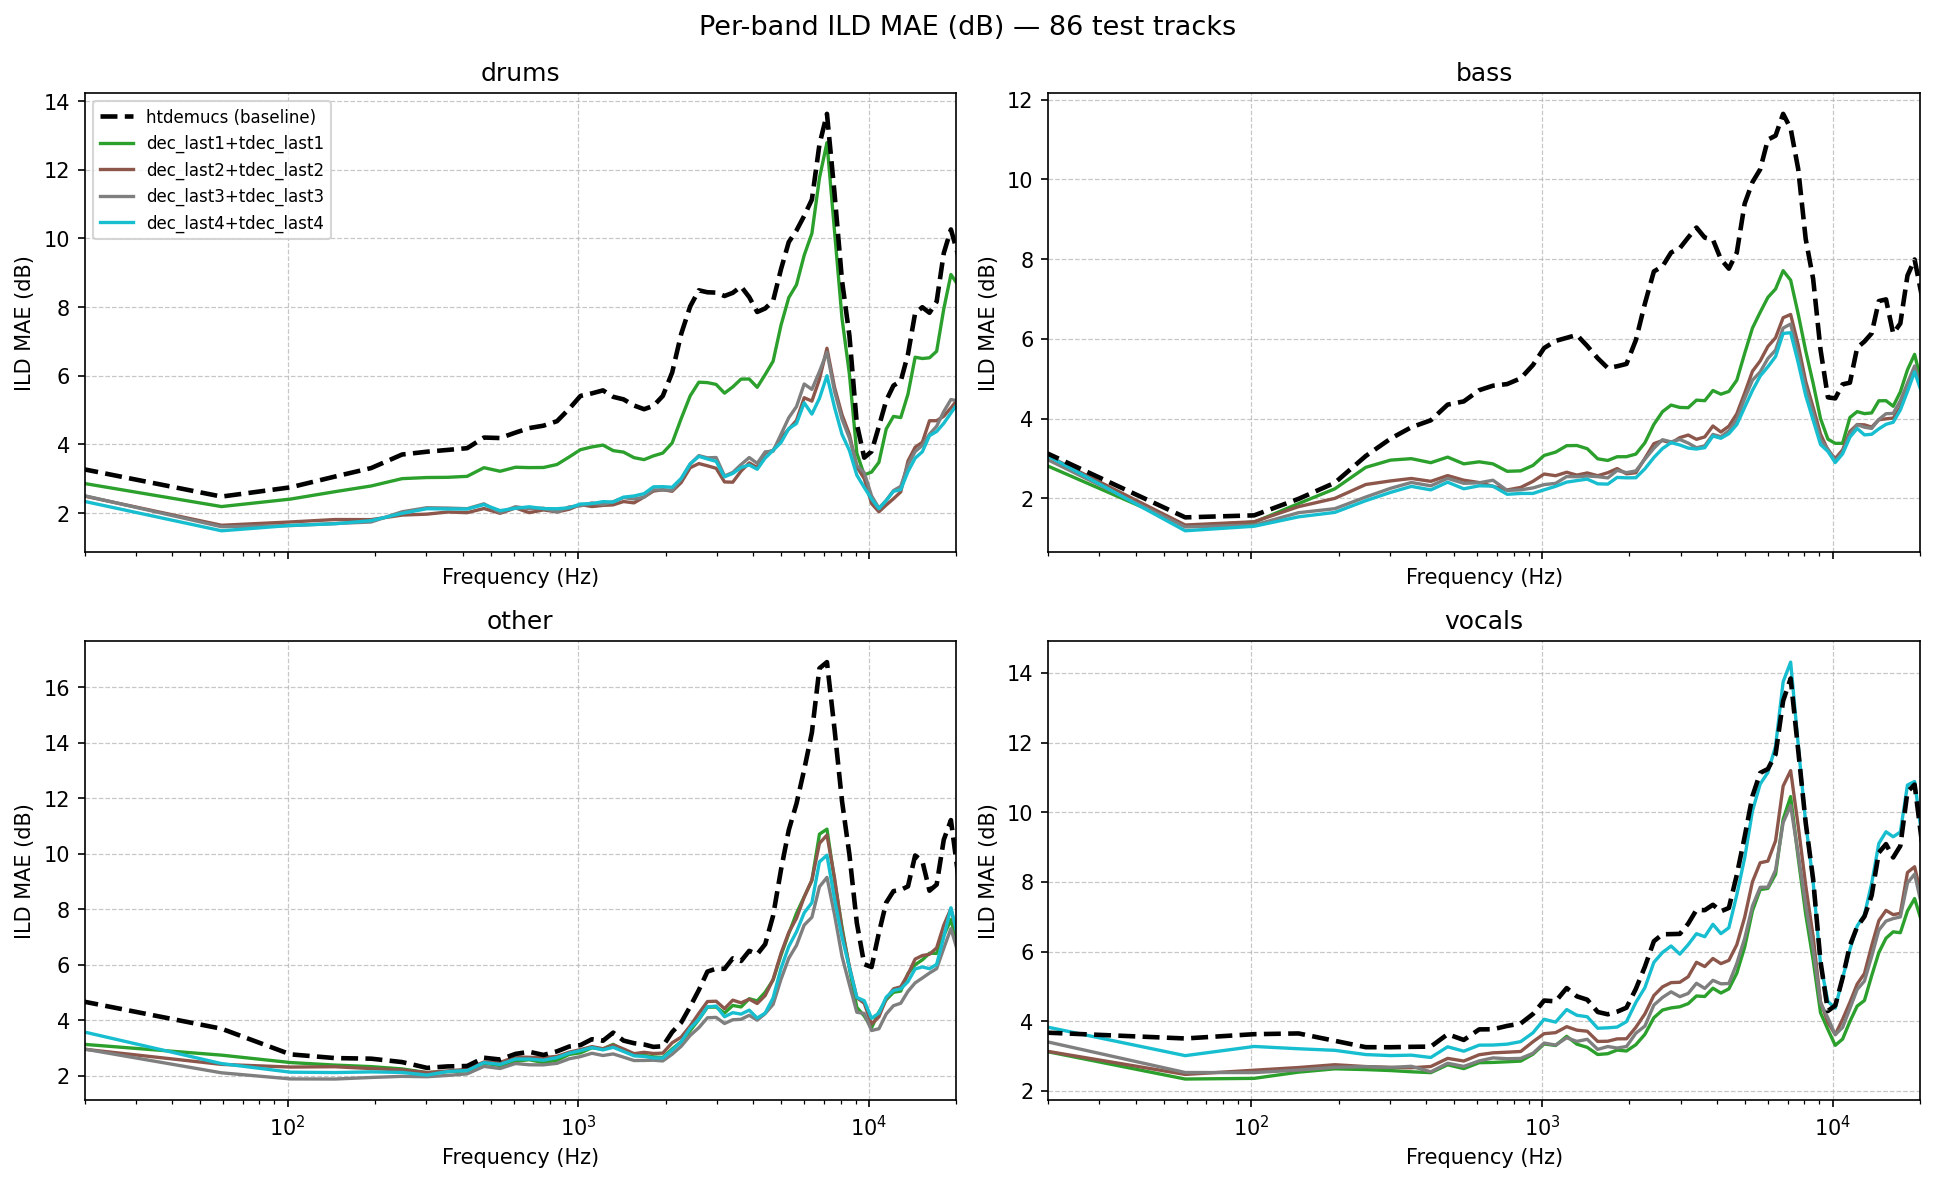

In [13]:
# Band centre frequencies (x-axis): mean Hz per Mel band, or linear midpoints.
n_bands = EVAL["n_bands"]
if EVAL["scale"] == "mel":
    _ba     = mel_bin_assignment(int(EVAL["n_fft"]), n_bands, int(SAMPLE_RATE))
    _bin_hz = np.arange(int(EVAL["n_fft"]) // 2 + 1) * (int(SAMPLE_RATE) / int(EVAL["n_fft"]))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

def mean_bands(ag, src, key):
    return np.mean(ag[src][key], axis=0)   # (n_bands,)

# One distinct colour/style per model; baseline is a thick black dashed line.
_labels = ([BASELINE_LABEL] if BASELINE_LABEL in agg_by_model else []) + \
          [l for l in agg_by_model if l != BASELINE_LABEL]
_cmap = plt.cm.tab10(np.linspace(0, 1, max(len(_labels), 1)))

def _style(label, i):
    if label == BASELINE_LABEL:
        return dict(color="black", lw=2.2, ls="--", zorder=3)
    return dict(color=_cmap[i], lw=1.6, ls="-")

def plot_metric(key, ylabel, scale=1.0):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=150, sharex=True)
    for ax, src in zip(axes.ravel(), SOURCES):
        for i, label in enumerate(_labels):
            ag = agg_by_model[label]
            if not ag[src][key]:
                continue
            ax.plot(band_hz, mean_bands(ag, src, key) * scale, label=label, **_style(label, i))
        ax.set_xscale("log")
        ax.set_xlim(20, 20000)
        ax.set_title(src)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
    axes.ravel()[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"Per-band {ylabel} — {len(tracks)} test tracks", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_metric("ild_bands_mae", "ILD MAE (dB)")

if COMPUTE_ITD:
    _US = 1e6 / SAMPLE_RATE   # µs per sample (≈ 22.68 µs @ 44.1 kHz)
    plot_metric("itd_bands_mae", "ITD MAE (µs)", scale=_US)